### Parte 2: Creación del input


Las variables con las que se trabajará provienen del trabajo [Downscaling of surface wind forecasts using convolutional neural networks](https://npg.copernicus.org/articles/30/553/2023/npg-30-553-2023.html). En este trabajo se proponen un conjunto de 35 variables detalladas en la siguiente tabla en donde se incluyen variables asociadas directamente al viento, variables meteorológicas complementarias, variables topográficas y la gran novedad: variables que describen la interacción del viento con la topografía.

<div style="text-align: center;">
    <img src="img/tablas_variables.png" alt="Variables propuestas por Dupuy (2023)" style="width: 600px;">
    <p>Figura 1: Variables propuestas por Dupuy (2023)</p>
</div>

Debido a que trabajar con todas estas variables puede conllevar a trabajar con información redudante y/o no significativa, nuestra propuesta inicial es preparar  un puñado pequeño de variables que tengan una estricta relación con el viento superficial y a partir de ahí, ir integrando nueva información para poder identificar su impacto en el rendimiento de nuestros modelos. Las propuestas son las siguientes: 

<center>

| Propuesta | Variables | 
| -------   | --------  |
| 1         | U10, V10, TH2, PBLH, HGT, XLAND | 
| 2         | + T2, PSFC | 
| 3         | + Slope, Aspect | 
| 4         | + Exposure $E_{+}$, Sheltering  $E_{-}$

</center>

A continuación se muestra una breve descripción de cada variable: 

<center>

| Variables | Descripción | Unidad |
| -------   | --------  | -----  |
| U10       | X-viento a 10 metros| $ms^{-1}$ |
| V10       | Y-viento a 10 metros| $ms^{-1}$ |
| TH2       | Temperatura potencial a 2m | K | 
| PBLH | PBL height  | m | 
| HGT | Terrain Height | m |
| XLAND | Land mask  | (1 for land, 2 for water)  |
| Slope | Pendiente con sus vecinos | degree | 
|  Aspect |  Dirección hacia donde la pendiente es más negativa | - |
| $E_{+}$ y $E_{-}$ | Refleja lugares expuestos al viento (exposure) o protegidos de él (sheltering) | - |

</center>


Información adicional: 
- PBLH: Planetary Boundary Layer Height se define generalmente como la altitud de una capa de transición donde el gradiente de temperatura o humedad del aire es significativo dentro de los primeros 1-5 kilómetros por encima de la superficie.

- $E_{+}$ y $E_{-}$: Se calculan como el seno del ángulo vertical $\alpha$ que el vector del viento tendría que cambiar para ser paralelo a la pendiente (slope) manteniendo su azimut. Este ángulo se calcula simplemente a partir del ángulo de la pendiente y de $\delta$, el ángulo entre la dirección del viento y la orientación (aspect) [(WindTopo, 2022)](https://rmets.onlinelibrary.wiley.com/doi/full/10.1002/qj.4265)

#### 2.2. Construcción de los tensores: 

El objetivo ahora es construir los tensores de dimensiones: (n parches, 32, 32, m vars). Para ello, partimos trabajando con los archivos de la carpeta ```salidas_parche_32_32_bicubic``` que contiene los datos (cortados e interpolados) que queremos aumentar su resolución y los datos objetivos.

Lo primero será  crear una variable que contenga los parches asociados a cada caso y para cada variable. La estructura de la variable que contendrá toda la información será un diccionario anidado cuya key principal será la variable meteorológica respectiva y su diccionario interno contendrá dicha información para cada uno de los caso. Por ejemplo:

```

stack= { "U10" : { "caso_1" : valores, "caso_2", valores, ... , "caso_n": valores} },
          "HGT"        : { "caso_1" : valores, "caso_2: valores, ..., "caso_n": valores}
          ... , 
       {  "XLAND", {...}}

```



In [6]:
import tensorflow as tf 
import numpy as np 
import os 
import re

path= "data_example/"


var_names = ["U10", "V10", "wspd_wdir10_0", "wspd_wdir10_1", "TH2", "T2", "PBLH","PSFC", "XLAND", "HGT"]
fechas_tr= ["2022_12_12"]

Para una mejor comprensión de los detalles del código a continuación, tengamos en cuenta lo siguiente: 
- Cada caso contiene los archivos asociados a los dominios d03 y d05 en la misma carpeta. Por lo mismo, la importación de los archivos .npy se harán en una misma variable. Sin embargo, los primeros 120 archivos estarán asociados al dominio d03 y los siguientes al dominio d05.
- Cada carpeta contendrá 240 o 242 archivos dependiendo de si se simuló la hora 00:00 del quinto día simulado. Para tener una misma cantidad de archivos en todas las carpetas, se eliminaron los últimos archivos d03 y d05 de cada caso que contenga 242 simulaciones.
- Debido a la posible inestabilidad de WRF en las primeras horas de simulación, se tomó la decisión de eliminar las primeras 5 horas de cada fecha, lo que nos da un total de 115 archivos por dominio. 
- Para asegurarnos que hicimos la eliminación de archivos correctamente, se implementó un doble check muy casero (para cada caso y cada variable meteorológica) que compara la hora simulada del primer y último archivo d03 con la de los archivos d05. Para mayor detalle, la hora corresponde al número que sigue después de la fecha en el nombre de archivo, como ejemplo, se tiene que el archivo de nombre ``` 'wrfout_d03_2018-06-23_05%3A00%3A00.npy' ``` tiene como hora las 05 (va del 00 al 23)



In [12]:
def cargar_datos(fechas, var_names, path):
    """
    Carga archivos .npy de simulaciones WRF organizados por variable y fecha.
    
    Args:
        fechas: Lista de fechas (nombres de subcarpetas)
        var_names: Lista de nombres de variables
        path: Ruta base donde están las carpetas de variables
    
    Returns:
        dict: Diccionario con estructura {variable: {fecha: tensor}}
    """
    stack = {}

    for var in var_names:
        stack_casos = {}

        for caso in fechas:
            rutas_npys = os.path.join(path, var, caso)
            archivos_npy = sorted([f for f in os.listdir(rutas_npys) if f.endswith('.npy')])

            # Separar por dominio y tomar últimas 114 horas de cada uno
            d03 = [f for f in archivos_npy if '_d03_' in f][-114:]
            d05 = [f for f in archivos_npy if '_d05_' in f][-114:]

            # Cargar y concatenar
            parches = [np.load(os.path.join(rutas_npys, npy)) for npy in d03 + d05]

            stack_casos[caso] = parches if var == 'times' else tf.squeeze(tf.convert_to_tensor(parches))

        print(f"Var {var} done")
        stack[var] = stack_casos
    
    return stack

In [13]:
stack_tr = cargar_datos(fechas_tr, var_names, path)

Var U10 done
Var V10 done
Var wspd_wdir10_0 done
Var wspd_wdir10_1 done
Var TH2 done
Var T2 done
Var PBLH done
Var PSFC done
Var XLAND done
Var HGT done


In [11]:
print(f"For {var_names[0]}")
for caso in fechas_tr:
        print(f"Dim case {caso}: ", stack_tr[var_names[0]][caso].shape)

For U10
Dim case 2022_12_12:  (228, 156, 32, 32)


Al completar el proceso de importación de los archivos npy, se observó que cada variable meteorológica dentro de nuestro ```stack``` contiene un array de dimnesiones $(230, 156, 32, 32)$. La primera dimensión se refiere a los 230 archivos (115 d03 y 115 d05) importados, la segunda hace referencia a los 156 parches por cada archivo, y las últimas dos a las dimensiones de los parches. Si hacemos los cálculos, tenemos la siguiente cantidad de parches por variable: 

<center>

| Conjunto | Cantidad de parches | 
|  ------  |  ------------------ | 
| Entrenamiento | 16 casos $\times$ 115 registros $\times$ 156 cuadrantes = 287040 parches  | 
| Validación | 8 casos $\times$ 115 registros $\times$ 156 cuadrantes = 143520 parches  | 
| Testeo | 8 casos $\times$ 115 registros $\times$ 156 cuadrantes = 143520 parches  | 

</center>

Ahora bien, como nuestro objetivo es construir el input de fomato (n parches, 32, 32, m vars). Lo primero será separar los archivos de cada dominio y así comenzar a formar los datos que conformarán el conjunto de "baja resolución" y el conjunto "objetivo" (para el caso de las variables "U10" y "V10", para el resto de variables solo basta con seleccionar los primeros 115 archivos). Lo siguiente será implementar el método ```tf.reshape``` de tensorflow que permite permutar las dimensiones de un tensor. En este caso lo que haremos es unificar la primera dimensión con la segunda y luego concatenar este nuevo tensor -creado por caso- con el correspondiente a cada caso. Con esto hemos creado nuevos tensores de dimensiones (287040, 32, 32, 1) para cada variable meteorológica con la que se trabajará. 

Nota: Este mismo proceso será aplicado cuando se trabaje con el conjunto de validación y de testeo.

In [14]:
def reshape_tensor(stack, var, casos=fechas_tr, input=False):
    """
    Reshape de tensores concatenando todos los casos.

    Args:
        stack: Diccionario con los datos
        var: Nombre de la variable (string)
        casos: Lista de casos/fechas
        input: Si True toma primeros 114, si False toma últimos 114

    Returns:
        Tensor concatenado y reshaped
    """
    bloques = []

    for caso in casos:
        valores = stack[var][caso][:114] if input else stack[var][caso][114:]
        valores_reshape = tf.reshape(valores, (-1, valores.shape[2], valores.shape[3], 1))
        bloques.append(valores_reshape)

    bloque = tf.concat(bloques, axis=0)
    print(bloque.shape)

    return bloque

In [15]:
#Esenciales
u10_input    =reshape_tensor(var="U10",stack=stack_tr, input=True)
u10_target   =reshape_tensor(var="U10",stack=stack_tr, input=False)

v10_input    =reshape_tensor(var="V10",stack=stack_tr, input=True)
v10_target   =reshape_tensor(var="V10",stack=stack_tr, input=False)

dir_input   = reshape_tensor(var="wspd_wdir10_1", stack=stack_tr, input=True)
speed_input = reshape_tensor(var="wspd_wdir10_0", stack=stack_tr, input=True)

#target - estático 
hgt_target    =reshape_tensor(var="HGT",  stack=stack_tr, input=False)
xland_target  =reshape_tensor(var="XLAND",stack=stack_tr, input=False)

#input - dinámico
pblh_input   =reshape_tensor(var="PBLH", stack=stack_tr, input=True)
th2_input    =reshape_tensor(var="TH2",  stack=stack_tr, input=True)
t2_input     =reshape_tensor(var="T2",   stack=stack_tr, input=True)
psfc_input   =reshape_tensor(var="PSFC", stack=stack_tr, input=True)

(17784, 32, 32, 1)
(17784, 32, 32, 1)
(17784, 32, 32, 1)
(17784, 32, 32, 1)
(17784, 32, 32, 1)
(17784, 32, 32, 1)
(17784, 32, 32, 1)
(17784, 32, 32, 1)
(17784, 32, 32, 1)
(17784, 32, 32, 1)
(17784, 32, 32, 1)
(17784, 32, 32, 1)


#### Una rápida visualización de nuestros datos

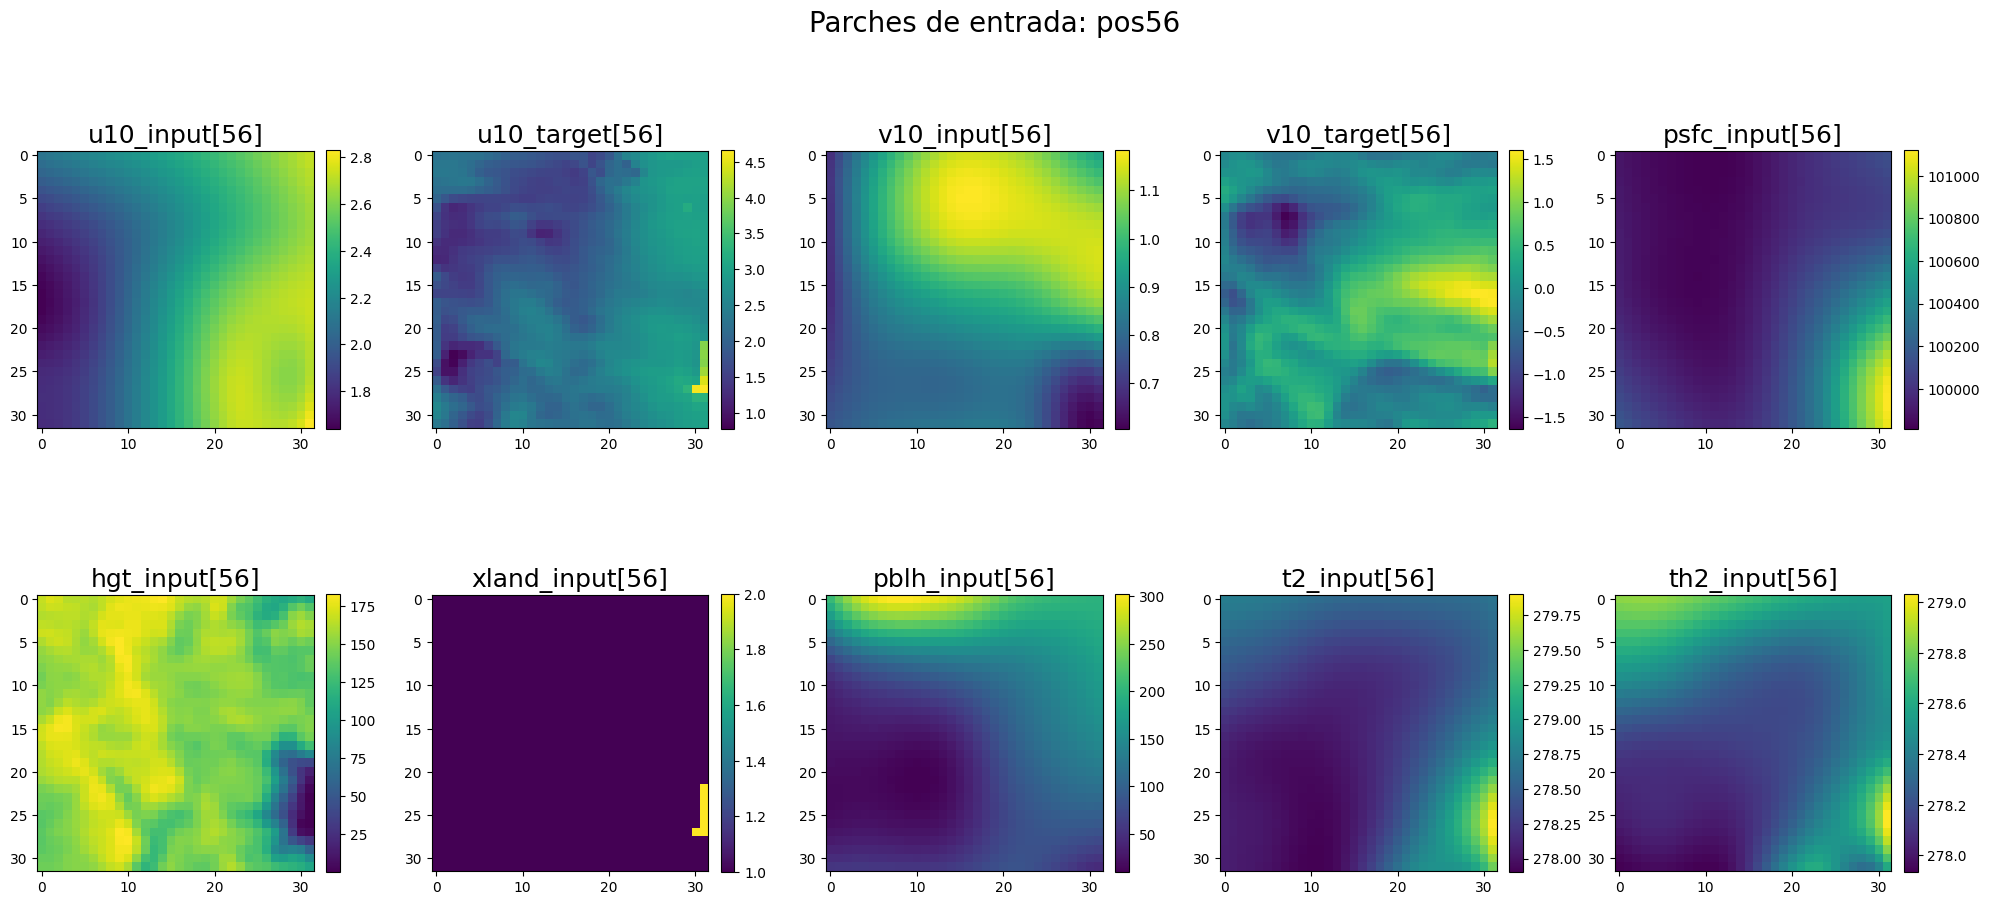

In [16]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import numpy as np


idx=56
datos      =[ u10_input,   u10_target,   v10_input,   v10_target,   psfc_input,   hgt_target,   xland_target,   pblh_input,   t2_input,   th2_input ]
nombres_var=["u10_input", "u10_target", "v10_input", "v10_target", "psfc_input", "hgt_input", "xland_input", "pblh_input", "t2_input", "th2_input"]

fig = plt.figure(figsize=(20, 10))
gs = GridSpec(2, 5, figure=fig)
fig.suptitle(f'Parches de entrada: pos{idx}', fontsize=20)
axes = [fig.add_subplot(gs[0, i]) for i in range(5)]
axes += [fig.add_subplot(gs[1, i]) for i in range(5)]

for i, ax in enumerate(axes):
    im = ax.imshow(tf.squeeze(datos[i][idx]), cmap='viridis', vmin=tf.reduce_min(datos[i]), vmax=tf.reduce_max(datos[i]))
    fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, shrink=0.8)
    ax.set_title(f'{nombres_var[i]}[{idx}]', fontsize=18)
    im.set_clim( np.min(tf.squeeze(datos[i][idx])), np.max(tf.squeeze(datos[i][idx])))

plt.tight_layout() 
plt.show()

#### Guardado de variables

Para efectos del guardado de variables, llamaremos ```bicubic_32_32``` a la carpeta que contendrá los arrays, "bicubic" se refiere a la interpolación utilizada y "32_32" a las dimensiones de los parches utilizados. Dentro de esta carpeta, los conjuntos de entrenamiento, validación y testeo tendrán su propia carpeta, por ejemplo, la carpeta del primer conjunto será ```190824_16_tr```, los primeros 6 dígitos hacen referencia a la fecha de cuando se crearon los datos, el segundo a la cantidad de casos utilizados y "tr" a la abreviación para "entrenamiento". Finalmente, debido a que cada variable input no ha sido normalizada (aún), añadiremos el sufijo "raw" haciendo alusión  a esta condición a cada ruta de guardado específica para cada variable. Eventualmente, cuando normalicemos estos datos, crearemos una carpeta llamada "norm" para el almacenamiento de estos nuevos datos. 

In [18]:
def guardado_parches(parches, nombre_parches, carpeta, opcional='', verbose=False):
    ruta_completa = os.path.join(carpeta, nombre_parches + opcional + '.npy')
    np.save(ruta_completa, parches)
    if verbose:
        print("Parches guardados exitosamente como: ", ruta_completa)

In [22]:
fecha= "parches_TR" #cambiar manualmente a va según corresponda
interp="bicubic_32_32/"
ruta_guardado="parches/TR/RAW" #se recomienda sacar la carpeta

if not os.path.exists(ruta_guardado):
    
    os.makedirs(ruta_guardado)

    #Esencial
    guardado_parches(u10_input,    "u10_input_raw_",     ruta_guardado, fecha)
    guardado_parches(u10_target,   "u10_target_raw_",    ruta_guardado, fecha)

    guardado_parches(v10_input,    "v10_input_raw_",     ruta_guardado, fecha)
    guardado_parches(v10_target,   "v10_target_raw_",    ruta_guardado, fecha)

    guardado_parches(speed_input,  "speed_input_raw_",   ruta_guardado, fecha)
    guardado_parches(dir_input,    "dir_input_raw_",     ruta_guardado, fecha)

    #Target - estático
    guardado_parches(hgt_target,   "hgt_target_raw_",    ruta_guardado, fecha)
    guardado_parches(xland_target, "xland_target_raw_",  ruta_guardado, fecha)


    #Input - Dinámico
    guardado_parches(pblh_input,    "pblh_input_raw_",   ruta_guardado, fecha)
    guardado_parches(psfc_input,    "psfc_input_raw_",   ruta_guardado, fecha)
    guardado_parches(th2_input,     "th2_input_raw_",    ruta_guardado, fecha)
    guardado_parches(t2_input,      "t2_input_raw_",     ruta_guardado, fecha)


                
    print("Parches guardados correctamente")
                
else:

    print("Ya existen variables guardadas en esa carpeta")

Parches guardados correctamente
